In [1]:
import torch 
import torch_geometric
from torch_geometric.data import Data, DataLoader, InMemoryDataset
import numpy as np
import matplotlib.pyplot as plt
import os
from torch import nn, Tensor
from sklearn.datasets import make_moons
import torch.nn.functional as F
from torch.autograd import grad
from torchdiffeq import odeint
from torch.utils.data import  TensorDataset
from torchvision import datasets, transforms
import math

C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch_cluster\_grid_cuda.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\nasso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCach

In [2]:
trajectories = [np.load(f"../../data/boids/raw/{f}") for f in os.listdir("../../data/boids/raw") if f.endswith(".npy")]
print(len(trajectories))

26


In [3]:
print("Single trajectory shape:")
print(trajectories[0].shape)
print("The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)")

Single trajectory shape:
(1000, 25, 4)
The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)


In [4]:
# Print the mean, std, min and max of the boid positions, velocities
positions = np.array([t[:, :, :2] for t in trajectories])
velocities = np.array([t[:, :, 2:] for t in trajectories])

print("Position mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(positions),2), round(np.std(positions),2), round(np.min(positions), 2), round(np.max(positions), 2))
print()
print("Velocity mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(velocities),2), round(np.std(velocities),2), round(np.min(velocities), 2), round(np.max(velocities), 2))

Position mean, std, min, max:
500.32 290.61 0.0 1000.0

Velocity mean, std, min, max:
-0.35 2.96 -6.0 6.0


In [5]:
def plot_state(trajectory, timestep):
    fig, ax = plt.subplots()
    # Plot dots for the boids
    ax.scatter(trajectory[timestep, :, 0], trajectory[timestep, :, 1])
    # plot the boid velocities as arrows
    for i in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        ax.arrow(trajectory[timestep, i, 0], trajectory[timestep, i, 1], trajectory[timestep, i, 2]*5, trajectory[timestep, i, 3]*5)
    return ax

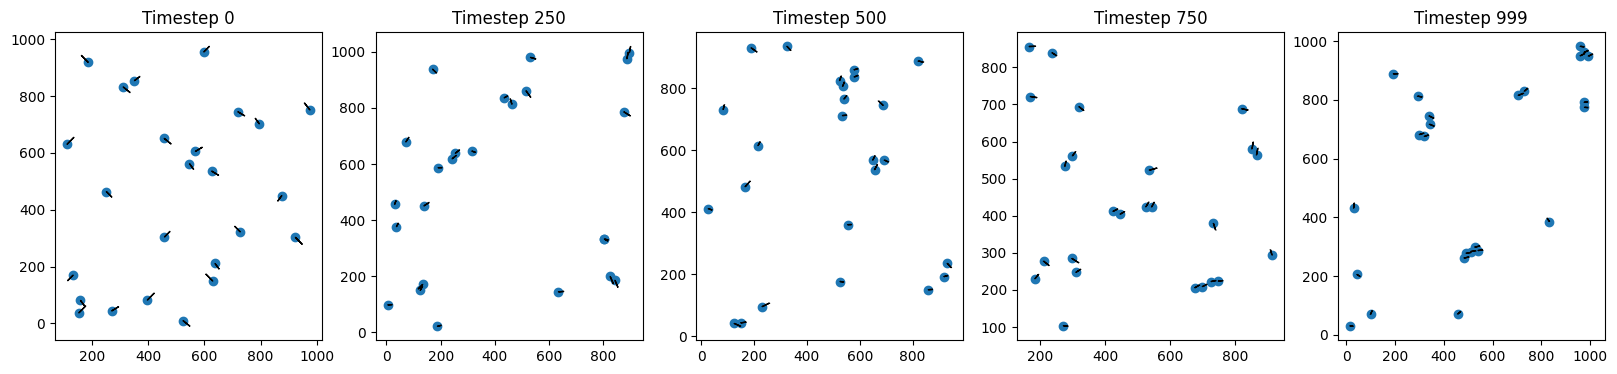

In [6]:
# Plot timesteps 0, 250, 500, 750, 999 for the first trajectory
trajectory = trajectories[0]
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, t in enumerate([0, 250, 500, 750, 999]):
    axs[i].set_title(f"Timestep {t}")
    # Plot dots for the boids
    axs[i].scatter(trajectory[t, :, 0], trajectory[t, :, 1])
    # plot the boid velocities as arrows
    for j in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        axs[i].arrow(trajectory[t, j, 0], trajectory[t, j, 1], trajectory[t, j, 2]*5, trajectory[t, j, 3]*5)
plt.show()

In [7]:
class Boids_Dataset(InMemoryDataset):
    def __init__(self, raw_data_path, processed_data_path, root=None,
                 transform=None, pre_transform=None, post_transform=None,
                 solution_idx_range=(0, 25), timesteps=1000,
                 processed_file_name="AR1_Boids_Equivariant.pt", L=1000):
        self.raw_data_path = raw_data_path
        self.processed_data_path = processed_data_path
        self.solution_idx_range = solution_idx_range
        self.timesteps = timesteps
        self.processed_file_name = processed_file_name
        self.pre_transform = pre_transform
        self.transform = transform
        self.post_transform = post_transform
        self.L = L
        super(Boids_Dataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def processed_file_names(self):
        return [self.processed_file_name]

    @property
    def raw_file_names(self):
        return [pfn for pfn in os.listdir(self.raw_data_path)
                if (self.solution_idx_range[0] <= int(pfn.split("_")[-1][:-4]) < self.solution_idx_range[1])]

    def download(self):
        pass

    def process(self):
        max_forward_steps = 5
        data_list = []
        all_init_positions = []   
        vmax = 0.0
        for raw_path in self.raw_file_names:
            trajectory = np.load(os.path.join(self.raw_data_path, raw_path))  
            vels = trajectory[:, :, 2:]  
            vmax = max(vmax, np.abs(vels).max())
        if vmax == 0:
            vmax = 1.0

        print(f"[Normalization] Using L={self.L}, vmax={vmax:.4f}")

        for raw_path in self.raw_file_names:
            trajectory = np.load(os.path.join(self.raw_data_path, raw_path))

            init_pos = torch.tensor(trajectory[0, :, :2], dtype=torch.float)  
            all_init_positions.append(init_pos)

            for t in range(trajectory.shape[0] - max_forward_steps):
                # current state
                pos_t = torch.tensor(trajectory[t, :, :2], dtype=torch.float) / self.L
                vel_t = torch.tensor(trajectory[t, :, 2:], dtype=torch.float) / vmax
                x = torch.cat([pos_t, vel_t], dim=-1) 

                pos_next = torch.tensor(trajectory[t+1, :, :2], dtype=torch.float) / self.L
                vel_next = torch.tensor(trajectory[t+1, :, 2:], dtype=torch.float) / vmax
                y = torch.cat([pos_next, vel_next], dim=-1)

                N = pos_t.shape[0]
                edge_index = torch.combinations(torch.arange(N), r=2, with_replacement=False).T
                edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
                senders, receivers = edge_index

                # relative displacement as edge attribute
                rel_disp = pos_t[receivers] - pos_t[senders]
                rel_disp = rel_disp - torch.round(rel_disp)
                edge_attr = rel_disp

                data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
                data_list.append(data)

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])

        all_init_positions = torch.stack(all_init_positions)   
        torch.save(all_init_positions, os.path.join(self.processed_data_path,
                                                    "positions_" + self.processed_file_name))
        print(f"Saved initial positions: {all_init_positions.shape}")
        
    def __getitem__(self, idx):
        return self.get(idx)
    
    def __repr__(self):
        return f'{self.__class__.__name__}({len(self)})'

In [8]:
train_dataset = Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(0, 15), timesteps=1000, processed_file_name="Boids4.pt")
validation_dataset = Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(16, 25), timesteps=1000, processed_file_name="VAL_Boids4.pt")

print(train_dataset)
print(validation_dataset)


data_0 = train_dataset[0]
print(data_0)
print(data_0.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_0.x[0,:])

Boids_Dataset(14925)
Boids_Dataset(8955)
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7190,  0.7450,  0.8333, -0.5000])


In [9]:
print(data_0.y[0,:])

data_1 = train_dataset[1]
print(data_1)
print(data_1.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_1.x[0,:])

print(data_1.y[0,:])

data_2 = train_dataset[2]
print(data_2)
print(data_2.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_2.x[0,:])

tensor([ 0.7240,  0.7420,  0.8333, -0.5000])
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7240,  0.7420,  0.8333, -0.5000])
tensor([ 0.7290,  0.7390,  0.8333, -0.5000])
Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], edge_attr=[600, 2], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([ 0.7290,  0.7390,  0.8333, -0.5000])


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.nn import MessagePassing

class EdgeGNNVectorField(MessagePassing):
    def __init__(self, hidden_dim=64, n_layers=2):
        super().__init__(aggr='mean')
        self.n_layers = n_layers

        # Edge MLP (shared across layers or separate per layer)
        self.edge_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(4, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])

        # Node MLP per layer
        self.node_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim + 4 + 4 + 1, hidden_dim), # added condition size
                nn.ReLU(),
                nn.Linear(hidden_dim, 4)
            ) for _ in range(n_layers)
        ])

    def forward(self, x_t, x_0, edge_index, t):
        current_edge_attr = self.compute_edge_attr(x_t, edge_index)
        h = x_t
        for i in range(self.n_layers):
            edge_msg = self.edge_mlps[i](current_edge_attr)
            # Message passing: aggregate messages from neighbors
            aggregated_messages = self.propagate(edge_index, x=h, edge_attr=edge_msg)
            
            # *** MODIFICATION: Concatenate h (x_t), the condition x_0, and time t ***
            # Note: We combine aggregated messages with the original node features (h)
            # and the condition (x_0) for the node update.
            node_input = torch.cat([aggregated_messages, h, x_0, t], dim=1)
            
            # Update node features
            h = self.node_mlps[i](node_input)
        return h

    def message(self, x_j, edge_attr):
        return edge_attr
    
    def compute_edge_attr(self, x, edge_index, L=1.0 ):
        row, col = edge_index
        
        pos = x[:, :2]
        vel = x[:, 2:]
        
        rel_pos = pos[col] - pos[row]
        rel_pos = rel_pos - L * torch.round(rel_pos / L)

        rel_vel = vel[col] - vel[row]
        return torch.cat([rel_pos, rel_vel], dim=1)

    @torch.no_grad()
    # *** MODIFICATION: Pass x0 as the condition to the forward call ***
    def generate(self, x0, edge_index, n_steps=50, dt=0.02, sigma=0.1, L=1.0):
        device = next(self.parameters()).device
        x = torch.randn_like(x0).to(device) # Start from noise
        traj = [x.cpu()]

        for i in range(n_steps):
            t_val = 1.0 - (i / n_steps) # Integrate from t=1 to t=0
            t = torch.full((x.size(0), 1), t_val, device=device)
            
            # The condition x0 is passed to the forward method
            v = self.forward(x, x0, edge_index, t)
            
            # Update step using Euler-Maruyama
            # The drift term is now the learned vector field v
            x = x - dt * (v + sigma * x) # This is one possible update rule (VP SDE)
            if sigma > 0:
                x = x + (2 * dt * sigma)**0.5 * torch.randn_like(x)

            # Apply periodic boundary conditions to positions
            x[:, :2] = x[:, :2] % L 
            traj.append(x.cpu())

        return torch.stack(traj)


def GFM_training_graph_conditional(VF, data, n_epochs=1000, sigma=0.1, device="cuda"):
    x_0 = data.x.to(device) # Starting state
    x_1 = data.y.to(device) # Target state
    
    VF = VF.to(device)
    edge_index = data.edge_index.to(device)
    optimizer = optim.Adam(VF.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    loss_hist = []

    print("Starting Conditional Flow Matching Training...")
    for epoch in range(n_epochs):

        t = torch.rand(x_0.size(0), 1).to(device)
        
        mu_t = (1 - t) * x_0 + t * x_1
        x_t = mu_t + sigma * torch.randn_like(x_0)

        u = x_1 - x_0

        pred_u = VF(x_t, x_0, edge_index, t)

        loss = loss_fn(pred_u, u)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_hist.append(loss.item())
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

    return VF, loss_hist


Starting Conditional Flow Matching Training...
Epoch 0000 | Loss: 0.009240
Epoch 0010 | Loss: 0.002134
Epoch 0020 | Loss: 0.001658
Epoch 0030 | Loss: 0.001485
Epoch 0040 | Loss: 0.001442
Epoch 0050 | Loss: 0.001430
Epoch 0060 | Loss: 0.001422
Epoch 0070 | Loss: 0.001417
Epoch 0080 | Loss: 0.001412
Epoch 0090 | Loss: 0.001409
Epoch 0099 | Loss: 0.001406


Text(0.5, 1.0, 'Training loss')

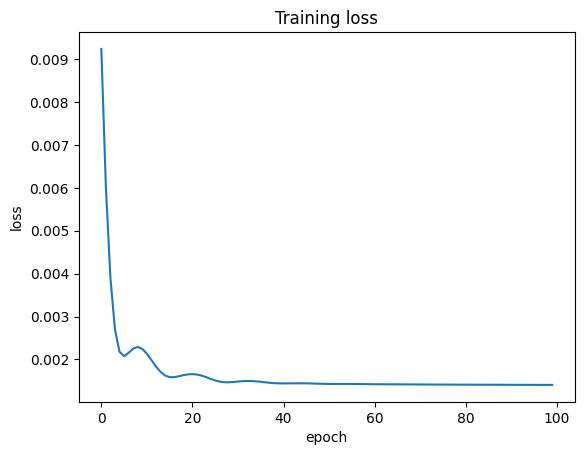

In [16]:
VF = EdgeGNNVectorField().to("cuda")
VF_GFM, loss_hist_GFM = GFM_training_graph_conditional(VF, train_dataset, n_epochs=100, sigma=0.1)
plt.plot(loss_hist_GFM)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss')

In [17]:
data = validation_dataset[0].to("cuda")

In [27]:
x0 = data.x.to("cuda")

with torch.no_grad():
    traj = VF.generate(
        x0=x0,
        edge_index=data.edge_index,
        n_steps=1000,
        dt=0.001,
        sigma=0.0,
    )

print(traj.shape)

torch.Size([1001, 25, 4])


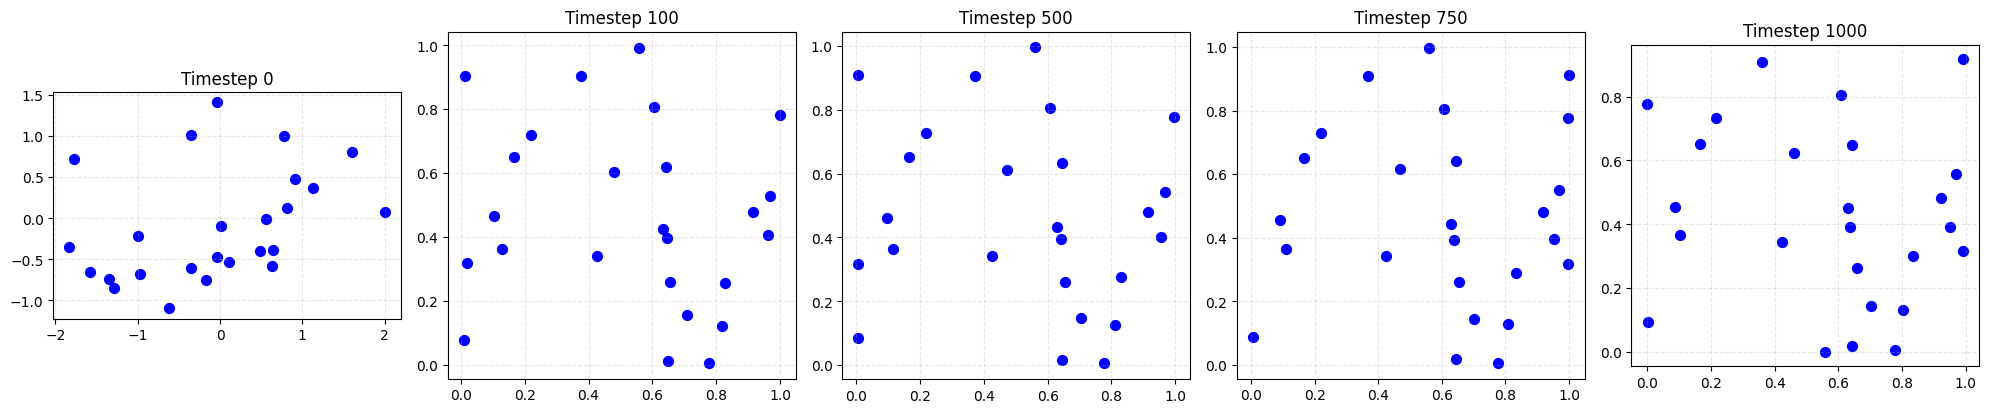

In [28]:
timesteps = [0, 100, 500, 750,1000] 

fig, axs = plt.subplots(1, len(timesteps), figsize=(20, 4))

for i, t in enumerate(timesteps):
    axs[i].scatter(traj[t, :, 0], traj[t, :, 1], color='blue', s=50)
    axs[i].set_title(f"Timestep {t}")

    axs[i].set_aspect('equal')
    axs[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()